## Frozen Lake


![Frozen Lake](https://gymnasium.farama.org/_images/frozen_lake.gif)


## On-Policy vs. Off-Policy Algorithms (T2)

In the context of Reinforcement Learning, algorithms are often divided into two families, On-policy and Off-policy ones. As the name implies, the first class relies directly on the policy being used, while the second class does something slightly different.

A good way to understand the difference is to look at the Q-Learning and SARSA update rules, which are often used as examples of, respectively, Off-policy and On-policy algs:

**Q-Learning:**

$Q(S_t,A_t) = Q(S_t,A_t) + \alpha\left(R_{t+1} + \gamma \max_{a'} Q(S_{t+1},a') - Q(S_t,A_t) \right)$

**SARSA:**

$Q(S_t,A_t) = Q(S_t,A_t) + \alpha\left(R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t,A_t) \right)$

**The Update Rule Difference:**
The only difference in the two update rules lies in what the qvalue of the next action is assumed to be. In Q-Learning, the Q-Table is updated on the base of the best value that could ideally be selected from the state $S_{t+1}$, indipendently from the actual policy being followed. With an epsilon-greedy policy, what happens is that a non greedy selection is made with probability $ϵ$, therefore the actual policy may differ from the "optimal" one the update rule uses. In this case, one often talks about the Behaviour Policy (the one being actually followed) and the Optimal Policy (the greedy one), which we are actually optmizing. Therefore we speak about Off-policy algorithms.

For SARSA instead, the qvalue of the next action is not assumed to be the best possible one assuming a greedy policy, but is calculated on the base of the policy, therefore we speak of On-policy algorithms.


**The difference in behaviour:**
This small difference actually makes the two algorithms behave in quite a different way, with On-policy algorithms being "optimistic" and Off-policy ones being very "cautious". The first ones select an action thinking about the best possible outcome while the second ones keep count of the possible deviations from the best choices due for example to an epsilon-greedy strategy, taking directly into account the probability of committing an error.

**No Memory Buffer:**
From this stems also another important difference which lies in the fact that, given that On-policy algorithms need to use the actual policy all the time, they can't re-use old data or data from other agents, as that doesn't correspond to the current policy anymore. This means they cannot be trained with a memory buffer, contrary to Off-policy algorithms which really are only interested in finding the theoritically optimal policy without caring for the behaviour policy. In other words, they are only interested in the objective characteristics of the environment being modeled and not the specific behaviour of the agent, and can therefore re-use old data without problems.

**Which algorithm should be used?**
Depending on the situation, one or the other family may be more appropriate. For example, in a situation in which we need to avoid errors because of safety reasons (a robot may be dangerous if it falls), one may prefer a more cautious On-policy algorithm. In other cases, the need for faster convergence or the use of memory buffers may make Off-policy algorithms the better choice.

# SARSA Implementation (T1)

In [ ]:
import numpy as np
import gymnasium as gym
import random
import matplotlib.pyplot as plt
import seaborn as sns

We focus on the more difficult slippery case throughout this notebook.

In [ ]:
env = gym.make("FrozenLake-v1", is_slippery=True, success_rate=0.8)

In [ ]:
action_size = env.action_space.n
state_size = env.observation_space.n

print(f"The qtable has dimensions {(int(state_size), int(action_size))}")

qtable_SARSA = np.zeros((16,4)) #Q-Table initialized at zero

The qtable has dimensions (16, 4)


## Hyperparameters

In [ ]:
epsilon = 0.3
epsilon_0 = epsilon
min_epsilon = 0.01
decay_rate = 0.001

gamma = 0.3
alfa = 0.3

total_episodes = 1200
max_steps = 100

## Training

As for q-learning, in many runs SARSA is not able to properly learn a strategy and the qtable remains at zero. When it finally finds a few rewards, it is able to learn and behave well.

In [ ]:
rewards_SARSA = []

for episode in range(total_episodes):
  state, _ = env.reset()
  step = 0
  done = False
  total_rewards = 0


  for step in range(max_steps):
    uniform_sample = np.random.rand()

    if uniform_sample > epsilon:
      action = np.argmax(qtable_SARSA[state,:])
    else:
      action = env.action_space.sample()

    new_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    if uniform_sample > epsilon:
      new_action = np.argmax(qtable_SARSA[new_state,:])
    else:
      new_action = env.action_space.sample()


    qtable_SARSA[state, action] = qtable_SARSA[state, action] + alfa*(reward + gamma*qtable_SARSA[new_state,new_action]*(1-done) - qtable_SARSA[state, action])
    total_rewards += reward
    state = new_state

    if done:
      break

  epsilon = min_epsilon + (epsilon_0 - min_epsilon)*np.exp(-decay_rate*episode)
  rewards_SARSA.append(total_rewards)

env.close()
print(qtable_SARSA)


[[8.55340156e-05 7.35199031e-04 4.32078531e-05 2.08830034e-05]
 [1.20762066e-04 4.25445718e-08 0.00000000e+00 9.01962502e-06]
 [1.63653560e-05 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [4.30936384e-05 2.75805965e-03 0.00000000e+00 8.90033917e-05]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.66430078e-03 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [8.53888934e-04 5.24315953e-04 5.13578581e-03 4.82284991e-04]
 [2.27706349e-04 4.30106763e-05 3.71689582e-02 2.35415689e-06]
 [8.44649648e-04 1.00432117e-01 4.95088173e-05 2.16704103e-04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.34623121e-07 1.18658460e-07 0.00000000e+00 6.62033343e-02]
 [4.69743033e-02 3.35980833e-01 5.92562685e-01 2.36260299e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.000000

#Q-Learning

In [ ]:
qtable = np.zeros((16,4))

In [ ]:
rewards = []

for episode in range(total_episodes):
  state, _ = env.reset()
  step = 0
  done = False
  total_rewards = 0


  for step in range(max_steps):
    # TODO: implement ε-greedy action selection

    uniform_sample = np.random.rand()

    if uniform_sample > epsilon:
      action = np.argmax(qtable[state,:])
    else:
      action = env.action_space.sample()


    new_state, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

    # TODO: implement the Q-learning update rule

    qtable[state, action] = qtable[state, action] + alfa*(reward + gamma*(np.max(qtable[new_state,:]))*(1-done) - qtable[state, action])

    total_rewards += reward


    state = new_state

    if done:
      break

  epsilon = min_epsilon + (epsilon_0 - min_epsilon)*np.exp(-decay_rate*episode)
  rewards.append(total_rewards)

env.close()
print(qtable)

[[2.53128903e-04 1.53928947e-03 4.26780188e-04 2.11737918e-04]
 [2.34991320e-04 1.01047281e-05 1.25507153e-05 4.99257521e-05]
 [4.17912787e-05 0.00000000e+00 0.00000000e+00 2.52136540e-06]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.94961220e-03 3.90783533e-03 5.98374017e-05 4.99701169e-04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.22771488e-06 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [4.56405350e-03 1.14206353e-03 1.41301272e-02 7.26275107e-03]
 [2.64774617e-02 3.65881031e-02 6.87216881e-02 1.56979443e-03]
 [1.28380836e-02 1.94706238e-01 1.92798942e-09 2.61600609e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.17257070e-03 6.39210736e-02 2.20363655e-01 3.89791536e-02]
 [6.71126090e-02 2.20190138e-01 8.57995818e-01 1.29051801e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.000000

#Performance comparison (T3)

To obtain a more useful comparison, we used the same parameters found by grid search for the q-learning in the non slippery case from the previous exercise. When the models don't get stuck (zero qtables), they offer rather similar end of training performances, with q-learning having a slight advantage (about a 5 to 20% depending on the run). The biggest difference is actually in the first part of the training, with q-learning able to find a good policy faster than SARSA, which instead needs usually nearly double the episodes.

This difference is coherent with what we said between On-policy and Off-policy approaches we talked about before. In the Frozen Lake environment, the more aggressive and direct style of q-learning means a faster convergence, and there aren't really any drawbacks in this case. We don't need to pay particular attention to any safety mechanism, as would be the case for example in robotics, or to avoid surpassing determined thresholds within some kind of simulation. In this case, an Off-policy algorithm is likely the best choice.

This analysis is however limited in that we only tried one set of parameters for the SARSA algorithm. Therefore, below we make again use of the same grid to see if other combinations may change the outcome.

In [ ]:
window_size = 100
moving_avg_rewards_SARSA = np.convolve(rewards_SARSA, np.ones(window_size)/window_size, mode='valid')
moving_avg_rewards = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')

In [ ]:
print(f"The last twenty moving averages from the Q-Learning approach: \n{moving_avg_rewards[-20:]}\n")
print(f"The last twenty moving averages from the SARSA approach: \n{moving_avg_rewards_SARSA[-20:]}\n")

The last twenty moving averages from the Q-Learning approach: 
[0.66 0.66 0.67 0.67 0.68 0.69 0.7  0.7  0.7  0.7  0.69 0.68 0.68 0.67
 0.67 0.67 0.66 0.66 0.65 0.65]

The last twenty moving averages from the SARSA approach: 
[0.5  0.5  0.5  0.5  0.49 0.48 0.49 0.48 0.49 0.49 0.48 0.48 0.48 0.49
 0.49 0.49 0.48 0.48 0.48 0.48]



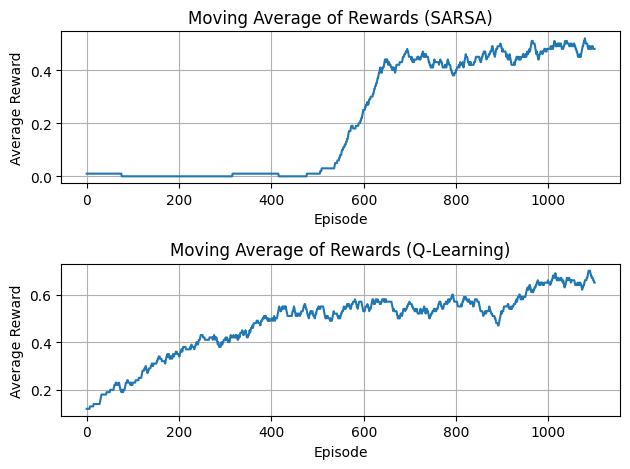

In [ ]:
fig, axs = plt.subplots(2,1)

axs[0].plot(moving_avg_rewards_SARSA)
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Average Reward")
axs[0].set_title("Moving Average of Rewards (SARSA)")
axs[0].grid(True)

axs[1].plot(moving_avg_rewards)
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Average Reward")
axs[1].set_title("Moving Average of Rewards (Q-Learning)")
axs[1].grid(True)

plt.tight_layout()
plt.show()

Regarding the final policies learned, while relying on a different approach, Q-Learning and SARSA end up with very similar policies. On more complex tasks one could think of observing distinctively different behaviour, but in this simple environment the differences are limited to slightly more efficient policies from Q-Learning on most runs.

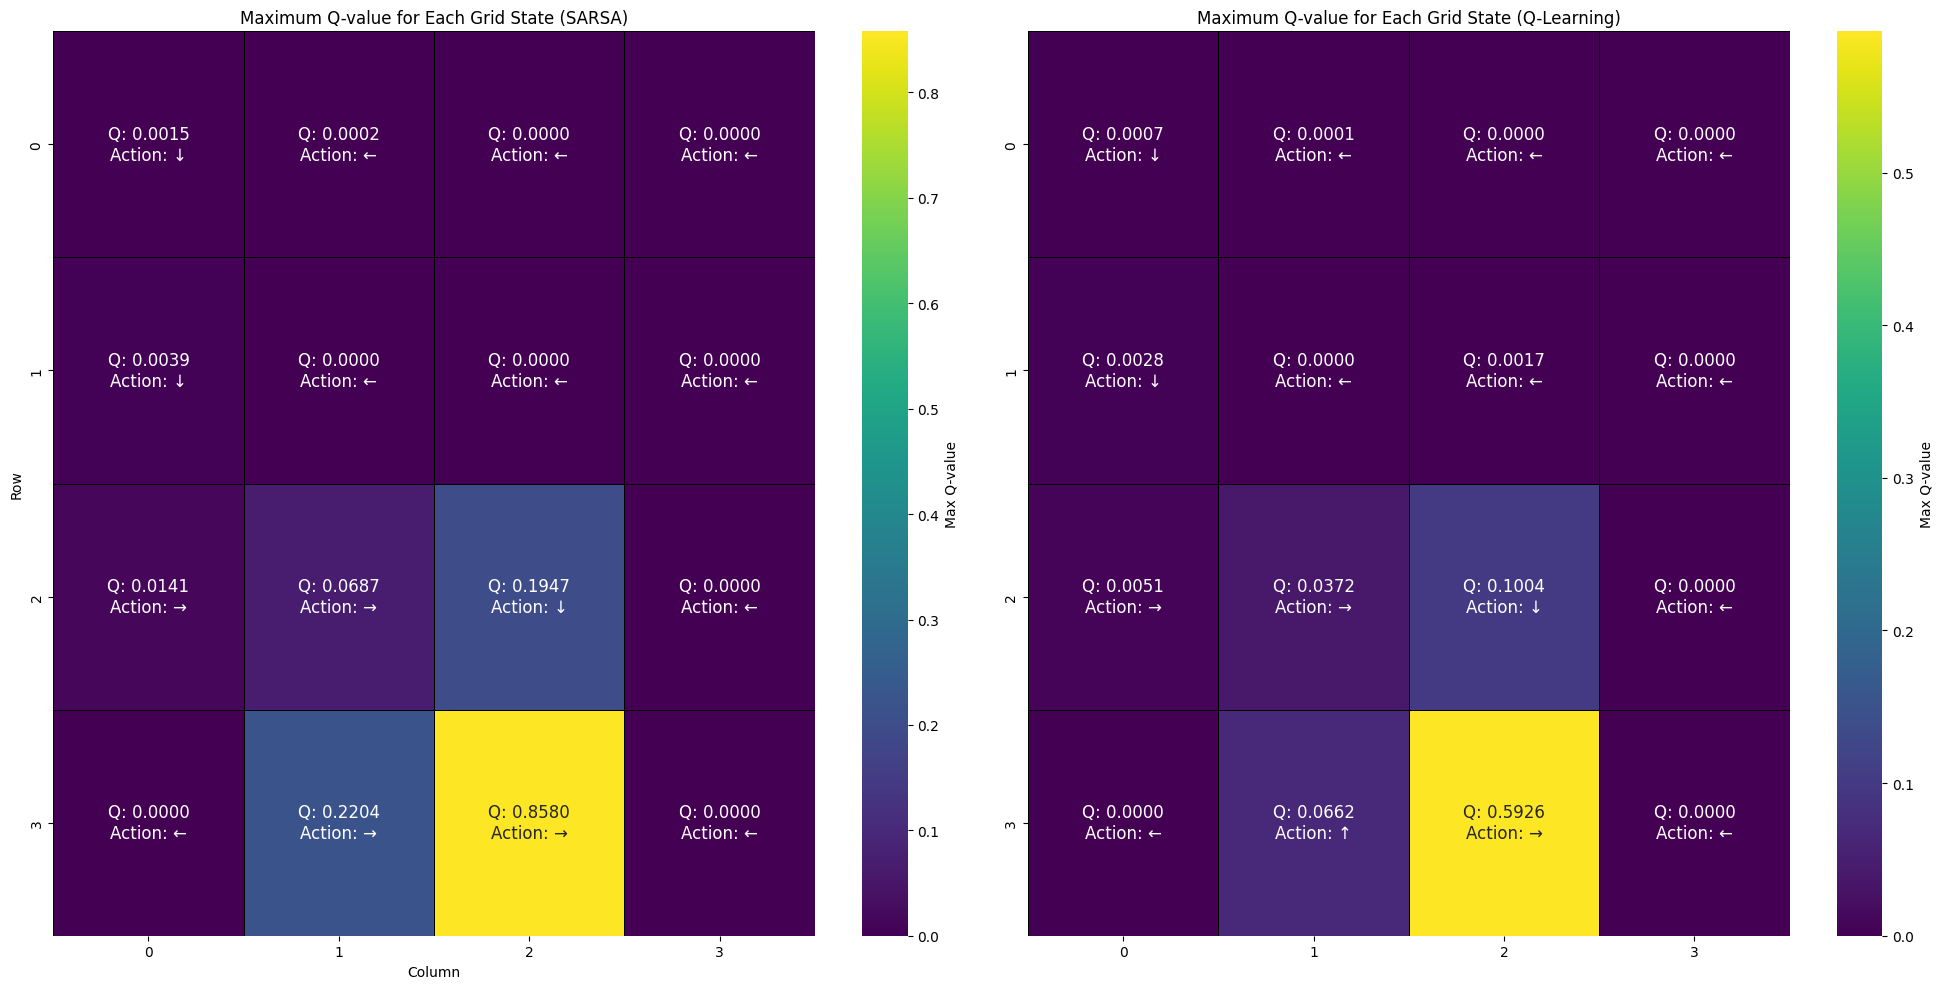

In [ ]:
action_symbols = {0: '←', 1: '↓', 2: '→', 3: '↑'}

#Q-Learning
max_q_values_ql = np.max(qtable, axis=1)
optimal_actions_ql = np.argmax(qtable, axis=1)
optimal_actions_symbols_ql = np.array([action_symbols[a] for a in optimal_actions_ql])

annotations_ql = []
for i in range(len(max_q_values_ql)):
    annotations_ql.append(f"Q: {max_q_values_ql[i]:.4f}\nAction: {optimal_actions_symbols_ql[i]}")

max_q_values_grid_ql = max_q_values_ql.reshape(4, 4)
annotations_grid_ql = np.array(annotations_ql).reshape(4, 4)

#SARSA
max_q_values_sarsa = np.max(qtable_SARSA, axis=1)
optimal_actions_sarsa = np.argmax(qtable_SARSA, axis=1)
optimal_actions_symbols_sarsa = np.array([action_symbols[a] for a in optimal_actions_sarsa])

annotations_sarsa = []
for i in range(len(max_q_values_sarsa)):
    annotations_sarsa.append(f"Q: {max_q_values_sarsa[i]:.4f}\nAction: {optimal_actions_symbols_sarsa[i]}")

max_q_values_grid_sarsa = max_q_values_sarsa.reshape(4, 4)
annotations_grid_sarsa = np.array(annotations_sarsa).reshape(4, 4)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.heatmap(max_q_values_grid_ql, annot=annotations_grid_ql, cmap="viridis", fmt="",
            linewidths=.5, linecolor='black', cbar_kws={'label': 'Max Q-value'}, cbar=True,
            annot_kws={"size": 12}, ax=axes[0])
axes[1].set_title("Maximum Q-value for Each Grid State (Q-Learning)")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Row")

sns.heatmap(max_q_values_grid_sarsa, annot=annotations_grid_sarsa, cmap="viridis", fmt="",
            linewidths=.5, linecolor='black', cbar_kws={'label': 'Max Q-value'}, cbar=True,
            annot_kws={"size": 12}, ax=axes[1])
axes[0].set_title("Maximum Q-value for Each Grid State (SARSA)")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Row")

plt.tight_layout()
plt.show()

#Checking Other Parameters Combination

A grid search over the same parameter space as the one used in the previous exercise confirms that SARSA doesn't reach the same success rate as Q-Learning, remaining a few percentage points lower (82% vs 90%). This gives new strenght to the conclusion reached in the previous paragraph. The best parameters for the SARSA are however different from the best found for the Q-Learning approach, with a higher learning rate and epsilon and a lower gamma. Perhaps this is due to statistical variance in this kind of tests or because the model is trying to simulate the aggressiveness of q-learning with a higher $α$ and a lower $γ$.

In [ ]:
alfa_values = [0.01, 0.1, 0.3, 0.5, 0.7, 0.9]
gamma_values = [0.1, 0.3, 0.5, 0.7, 0.9]
epsilon_0_values = [0.1, 0.3, 0.5, 0.7, 0.9]
decay_rate_values = [0.0001, 0.0005, 0.001]

print(f"Total number of combinations tested {len(alfa_values)*len(gamma_values)*len(epsilon_0_values)*len(decay_rate_values)}")

Total number of combinations tested 450


In [ ]:
import itertools #Permette di scrivere semplicemente il loop

best_reward = -np.inf
best_params = {}

#Fixed parameters
total_episodes_grid = 1200
max_steps_grid = 100
min_epsilon_grid = 0.01
window_size_grid = 100

env_grid = gym.make("FrozenLake-v1", is_slippery=False)
state_size_grid = env_grid.observation_space.n
action_size_grid = env_grid.action_space.n

#Iteration through all combinations
for alfa_val, gamma_val, epsilon_0_val, decay_rate_val in itertools.product(alfa_values, gamma_values, epsilon_0_values, decay_rate_values):
    print(f"\nTraining with: alfa={alfa_val}, gamma={gamma_val}, epsilon_0={epsilon_0_val}, decay_rate={decay_rate_val}")

    #Re-initialize Q-table for the current combination
    current_qtable = np.zeros((state_size_grid, action_size_grid))

    epsilon_current = epsilon_0_val
    epsilon_0_current = epsilon_0_val
    decay_rate_current = decay_rate_val
    gamma_current = gamma_val
    alfa_current = alfa_val

    current_rewards = []

    for episode in range(total_episodes_grid):
        state, _ = env_grid.reset()
        done = False
        total_episode_reward = 0

        for step in range(max_steps_grid):
            #epsilon-greedy selection
            if np.random.rand() > epsilon_current:
                action = np.argmax(current_qtable[state,:])
            else:
                action = env_grid.action_space.sample()

            new_state, reward, terminated, truncated, _ = env_grid.step(action)
            done = terminated or truncated

            if uniform_sample > epsilon:
              new_action = np.argmax(current_qtable[new_state,:])
            else:
              new_action = env.action_space.sample()

            #Update Rule (SARSA)
            current_qtable[state, action] = current_qtable[state, action] + alfa_current* \
                                            (reward + gamma_current*current_qtable[new_state, new_action]*(1 - done) - \
                                            current_qtable[state, action])

            total_episode_reward += reward
            state = new_state

            if done:
                break

        epsilon_current = min_epsilon_grid + (epsilon_0_current - min_epsilon_grid)*np.exp(-decay_rate_current*episode)
        current_rewards.append(total_episode_reward)

    #Average reward over the last window size episodes
    if len(current_rewards) >= window_size_grid:
        avg_reward = np.mean(current_rewards[-window_size_grid:])

    print(f"  Average reward over last {window_size_grid} episodes: {avg_reward:.4f}")

    #Save the best results
    if avg_reward > best_reward:
        best_reward = avg_reward
        best_params = {
            "alfa": alfa_val,
            "gamma": gamma_val,
            "epsilon_0": epsilon_0_val,
            "decay_rate": decay_rate_val
        }
        print(f"  New best reward found: {best_reward:.4f} with params: {best_params}")

env_grid.close()
print(f"Best average reward: {best_reward:.4f}")
print(f"Best hyperparameters: {best_params}")


Training with: alfa=0.01, gamma=0.1, epsilon_0=0.1, decay_rate=0.0001
  Average reward over last 100 episodes: 0.0000
  New best reward found: 0.0000 with params: {'alfa': 0.01, 'gamma': 0.1, 'epsilon_0': 0.1, 'decay_rate': 0.0001}

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.1, decay_rate=0.0005
  Average reward over last 100 episodes: 0.0000

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.1, decay_rate=0.001
  Average reward over last 100 episodes: 0.0000

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.3, decay_rate=0.0001
  Average reward over last 100 episodes: 0.0000

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.3, decay_rate=0.0005
  Average reward over last 100 episodes: 0.0000

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.3, decay_rate=0.001
  Average reward over last 100 episodes: 0.0000

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.5, decay_rate=0.0001
  Average reward over last 100 episodes: 0.0000

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.5, de

In [ ]:
print(f"Best hyperparameters found: {best_params}")
print(f"Highest average reward: {best_reward:.4f}")